## E-Commerce Hyper-Personalization Engine (Clustering & Classification)
### Phase 1: Advanced Data Exploration & Quality Assessment (EDA)

**Objective:** Inspect the raw transactional dataset, identify data anomalies, handle structural integrity issues, and outline a precise data cleaning strategy.

In [7]:
# 1. Import Core Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style for professional look
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Load the Dataset
try:
    # ISO-8859-1 encoding is required for this specific Kaggle retail dataset due to special characters
    df = pd.read_csv("data/data.csv", encoding='ISO-8859-1')
    print(f"Success: Dataset loaded with {df.shape[0]:,} rows and {df.shape[1]} columns.\n")
except FileNotFoundError:
    print("Error: Dataset not found. Please check your 'data/' folder path.")

Success: Dataset loaded with 541,909 rows and 8 columns.



In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### 1.1 Missing Value Analysis and Integrity Check
**Objective:** Identify the volume and percentage of missing data across all features to formulate an isolation or imputation strategy.

In [10]:
missing_data = df.isnull().sum()
missing_data_percent = (missing_data / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage': missing_data_percent
}).sort_values(by='Missing Values', ascending=False)

print("Missing Data Summary:")
missing_summary[missing_summary['Missing Values'] > 0]

Missing Data Summary:


,Missing Values,Percentage
CustomerID,135080,24.926694
Description,1454,0.268311


### 1.2 Statistical Distribution of Numerical Features
**Objective:** Compute descriptive statistics (mean, min, max, quartiles) for numerical features to detect structural anomalies like negative prices or quantities.

In [11]:
# Generate descriptive statistics for all numerical columns
print("--- Numerical Features Statistical Summary ---")
df.describe()

--- Numerical Features Statistical Summary ---


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### 1.3 Cardinality Assessment of Categorical Features
**Objective:** Evaluate the number of unique entities across high-cardinality features to understand the categorical dimensions of the dataset.

In [12]:
# Calculate unique values for key identification columns
categorical_summary = pd.DataFrame({
    'Feature': ['InvoiceNo', 'StockCode', 'Description', 'CustomerID', 'Country'],
    'Unique Counts': [df['InvoiceNo'].nunique(), df['StockCode'].nunique(), 
                     df['Description'].nunique(), df['CustomerID'].nunique(), 
                     df['Country'].nunique()]
})

print("--- Categorical Cardinality Summary ---")
print(categorical_summary.to_string(index=False))

# Show top 5 countries by transaction volume
print("\n--- Top 5 Countries by Transaction Volume ---")
print(df['Country'].value_counts().head())

--- Categorical Cardinality Summary ---
    Feature  Unique Counts
  InvoiceNo          25900
  StockCode           4070
Description           4223
 CustomerID           4372
    Country             38

--- Top 5 Countries by Transaction Volume ---
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Name: count, dtype: int64


### 1.4 Visual Data Quality Assessment
**Objective:** Present a clear, percentage-based diagnosis of the two primary data anomalies that jeopardize our Clustering and Classification pipelines:
1. **Anonymous Transactions:** Missing `CustomerID` values (Fatal for Clustering).
2. **Negative Transactions:** Cancelled or returned orders (Distorts RFM Metrics).

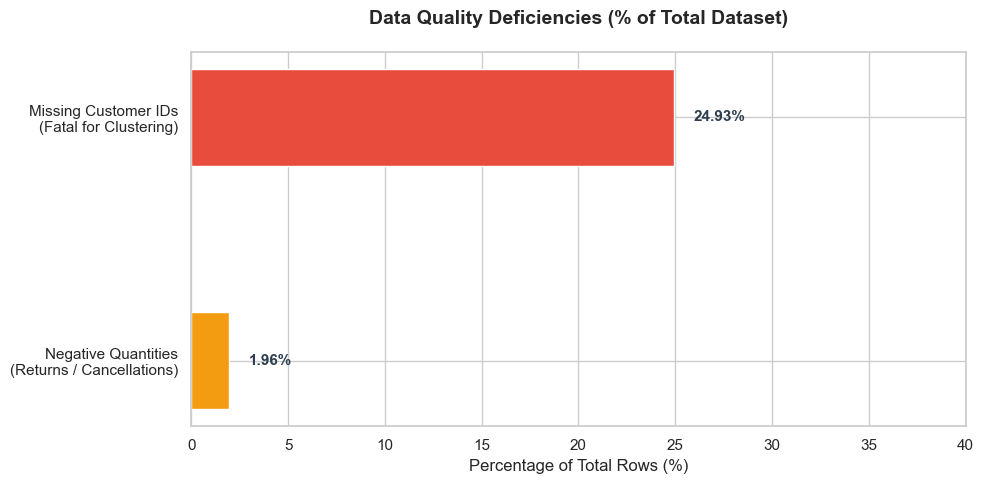

In [13]:
# 1. Calculate operational data issues as percentages of the entire dataset
total_rows = len(df)
missing_customer_pct = (df['CustomerID'].isnull().sum() / total_rows) * 100
negative_quantity_pct = ((df['Quantity'] < 0).sum() / total_rows) * 100

# 2. Structure the data for plotting
quality_metrics = ['Missing Customer IDs\n(Fatal for Clustering)', 'Negative Quantities\n(Returns / Cancellations)']
percentages = [missing_customer_pct, negative_quantity_pct]

# 3. Create a clean, highly readable horizontal bar chart
plt.figure(figsize=(10, 5))
bars = plt.barh(quality_metrics, percentages, color=['#e74c3c', '#f39c12'], height=0.4)

# 4. Refine aesthetics and add data labels
plt.title('Data Quality Deficiencies (% of Total Dataset)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Percentage of Total Rows (%)', fontsize=12)
plt.xlim(0, 40)  # Give some space for the text labels

# Add exact percentage labels on the tip of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.2f}%', 
             ha='left', va='center', fontweight='bold', fontsize=11, color='#2c3e50')

plt.gca().invert_yaxis()  # Put the most critical issue (Missing IDs) on top
plt.tight_layout()
plt.show()

## Phase 2: Data Cleaning & Preprocessing Blueprint

Based on our statistical and visual exploration, we will execute a 6-step robust data cleaning pipeline:

1. **Handle Missing Values:** Drop rows where `CustomerID` is null (since we cannot segment anonymous guests).
2. **Remove Cancellations:** Filter out transactions where `InvoiceNo` starts with 'C'.
3. **Eliminate Negative Values:** Remove rows with `Quantity` <= 0 or `UnitPrice` <= 0 to clean financial metrics.
4. **Fix Data Types:** Convert `CustomerID` to integer strings and `InvoiceDate` to proper datetime format.
5. **Geographical Filtering:** Restrict the scope to `United Kingdom` to mitigate severe country imbalance.
6. **Outlier Mitigation:** Apply statistical clipping or filtering on extreme `Quantity` and `UnitPrice` values.

In [14]:
# 1. Handle Missing Values (Drop Anonymous Transactions)
df_clean = df.dropna(subset=['CustomerID']).copy()
print(f"After dropping missing CustomerIDs: {df_clean.shape[0]:,} rows remain.")

# 2. Remove Cancellations (InvoiceNo starts with 'C')
# Convert to string first to ensure safety during vectorized string operations
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print(f"After removing cancellations: {df_clean.shape[0]:,} rows remain.")

# 3. Eliminate Negative & Zero Values in Numerical Features
# Filter out rows where Quantity <= 0 or UnitPrice <= 0
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(f"After removing negative/zero Quantity and UnitPrice: {df_clean.shape[0]:,} rows remain.")

# 4. Fix Data Types (Ensure proper formats to prevent data leakage)
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
print("\nData types after cleaning:")
print(df_clean.dtypes)

# 5. Geographical Filtering (Resolve Severe Country Imbalance by focusing on UK)
df_clean = df_clean[df_clean['Country'] == 'United Kingdom']
print(f"After geographical filtering (UK only): {df_clean.shape[0]:,} rows remain.")

# 6. Outlier Mitigation using Statistical IQR (Interquartile Range) Method
# We isolate and clip extreme outliers in Quantity and Price that distort clusters
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Filtering the dataframe within bounds
    return dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)]

df_clean = remove_outliers_iqr(df_clean, 'Quantity')
df_clean = remove_outliers_iqr(df_clean, 'UnitPrice')

print(f"Mitigated extreme outliers using IQR method. Final clean rows: {df_clean.shape[0]:,}\n")

print("Data Cleaning Pipeline Executed Successfully!")
print(f"Total Rows Eliminated: {df.shape[0] - df_clean.shape[0]:,} rows (Data efficiency optimized).")

After dropping missing CustomerIDs: 406,829 rows remain.
After removing cancellations: 397,924 rows remain.
After removing negative/zero Quantity and UnitPrice: 397,884 rows remain.

Data types after cleaning:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
dtype: object
After geographical filtering (UK only): 354,321 rows remain.
Mitigated extreme outliers using IQR method. Final clean rows: 305,129

Data Cleaning Pipeline Executed Successfully!
Total Rows Eliminated: 236,780 rows (Data efficiency optimized).


## Phase 3: RFM (Recency, Frequency, Monetary) Feature Engineering

**Objective:** Transform the transaction-level dataset into a customer-level behavior dataset by calculating the three core marketing metrics:
1. **Recency:** Days since the customer's last purchase (relative to the snapshot date).
2. **Frequency:** Total number of unique invoices associated with the customer.
3. **Monetary:** Total monetary value spent by the customer.

In [15]:
# 1. Calculate Total Spend for each individual transaction line
df_clean['Total_Spend'] = df_clean['Quantity'] * df_clean['UnitPrice']

# 2. Establish a "Snapshot Date" to calculate Recency
# We take the max date in the dataset and add 1 day to simulate "today's evaluation date"
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Simulation Snapshot Date: {snapshot_date.strftime('%Y-%m-%d')}\n")

# 3. Aggregate data per CustomerID using named aggregations
rfm_df = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Total_Spend', 'sum')
).reset_index()

# 4. Preview the newly engineered customer profile dataset
print(f"RFM Dataset Created! Total Unique Customers for Segmentation: {rfm_df.shape[0]:,}")
print("\n--- RFM DataFrame Preview ---")
rfm_df.head()

Simulation Snapshot Date: 2011-12-10

RFM Dataset Created! Total Unique Customers for Segmentation: 3,784

--- RFM DataFrame Preview ---


,CustomerID,Recency,Frequency,Monetary
0,12747,2,11,2640.41
1,12748,1,196,21046.63
2,12749,4,5,2737.73
3,12820,3,4,923.62
4,12821,214,1,75.72


## Phase 4: Customer Segmentation using K-Means Clustering

**Objective:** Scale the engineered RFM features to prevent scale dominance, apply the Elbow Method to algorithmically identify the optimal number of clusters ($K$), and train the K-Means model to segment the customer base.

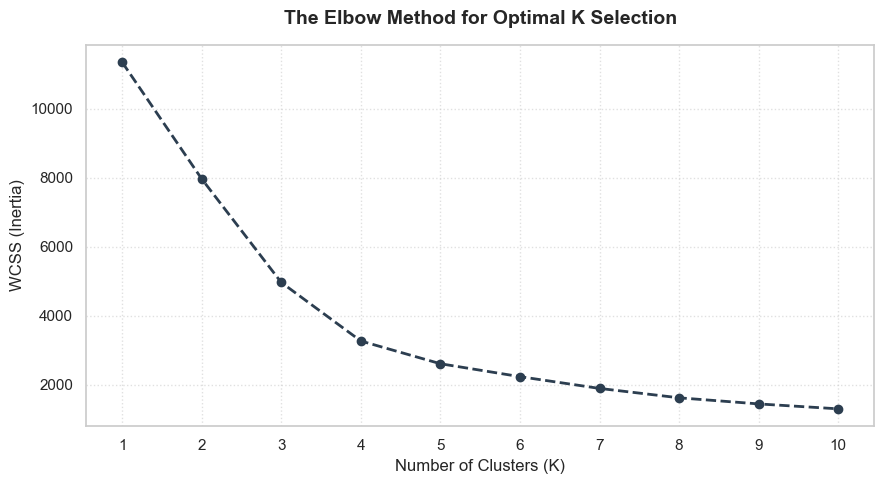

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Isolate the features for clustering (excluding the CustomerID string)
features = ['Recency', 'Frequency', 'Monetary']
X = rfm_df[features]

# 2. Apply StandardScaler to normalize the scaling metrics
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Execute the Elbow Method to find the optimal 'K'
wcss = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 4. Plot the Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(cluster_range, wcss, marker='o', linestyle='--', color='#2c3e50', linewidth=2)
plt.title('The Elbow Method for Optimal K Selection', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(cluster_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 1.5 Training the Final K-Means Model ($K=3$) & Profiling Clusters
**Objective:** Train the final KMeans algorithm with 3 clusters, assign a segment label to each customer, and calculate the mean RFM values per cluster to understand customer behavior.

In [17]:
# 1. Initialize and fit the final KMeans model with K=3
final_kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
rfm_df['Cluster'] = final_kmeans.fit_transform(X_scaled).argmin(axis=1) 

# 2. Profile the clusters by calculating the average RFM values for each segment
cluster_profile = rfm_df.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

# Calculate the percentage of customers in each cluster
cluster_profile['Customer_Share (%)'] = (cluster_profile['Customer_Count'] / rfm_df.shape[0]) * 100

print("--- 📊 Customer Profiles per Cluster ---")
cluster_profile.round(2)

--- 📊 Customer Profiles per Cluster ---


,Cluster,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Share (%)
0,0,953,243.77,1.51,287.06,25.18
1,1,171,12.59,23.21,6393.88,4.52
2,2,2660,42.44,3.66,877.02,70.30


### 1.6 Visualizing Customer Segments (RFM Snake Plot)
**Objective:** Construct a normalized line plot (Snake Plot) across the RFM features to visually differentiate the behavioral characteristics of each customer cluster.

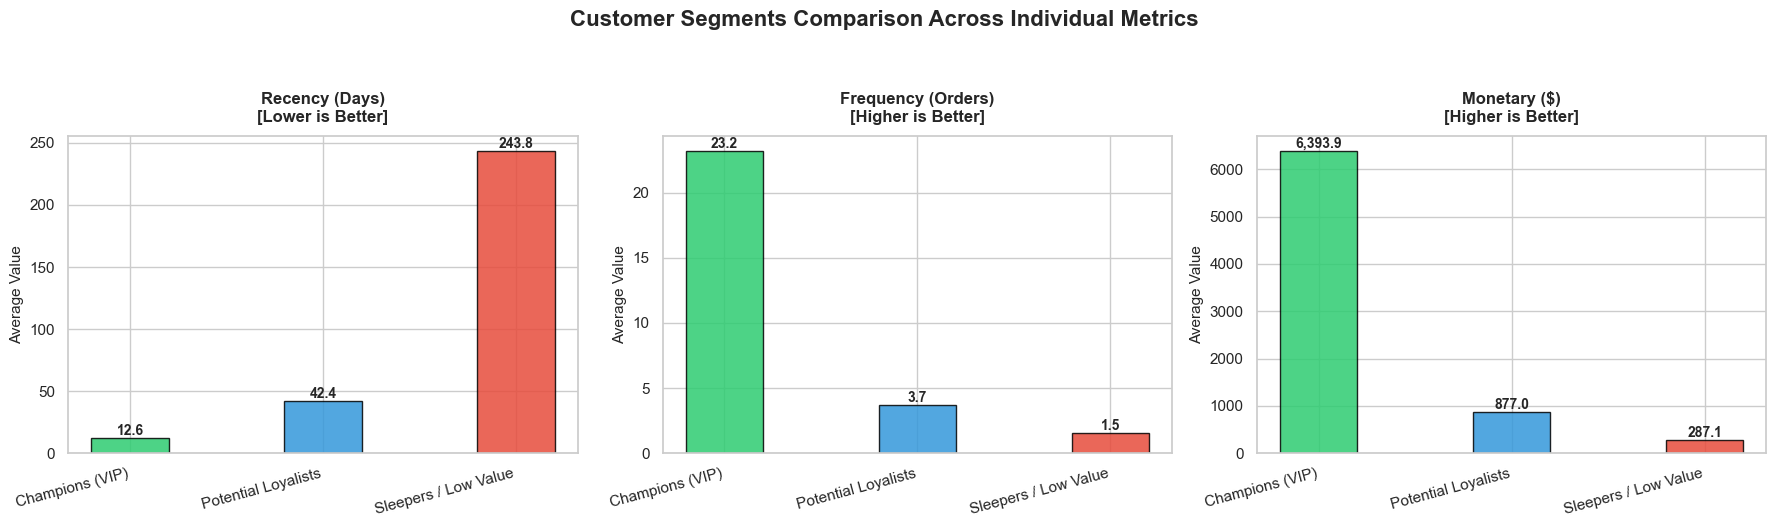

In [27]:
# ==============================================================================
# CLEANED SEPARATE MARKETING METRICS PLOT (NO WARNINGS)
# ==============================================================================

import numpy as np

# Configure 3 side-by-side plots: One for Recency, One for Frequency, One for Monetary
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer Segments Comparison Across Individual Metrics', fontsize=16, fontweight='bold', y=1.05)

# Metrics and titles mapping
metrics = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary']
titles = ['Recency (Days)\n[Lower is Better]', 'Frequency (Orders)\n[Higher is Better]', 'Monetary ($)\n[Higher is Better]']

# Clean names without emojis to prevent font rendering warnings
clean_personas = persona_profile['Persona'].str.replace(r'[^\w\s\(\)/]', '', regex=True).str.strip()

for i, (ax, metric, title) in enumerate(zip(axes, metrics, titles)):
    # Plot bars comparing the 3 personas for this specific metric
    bars = ax.bar(clean_personas, persona_profile[metric], 
                  color=persona_profile['Color'], width=0.4, edgecolor='black', alpha=0.85)
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Average Value', fontsize=11)
    
    # FIX 1: Set fixed ticks location before setting labels to resolve the UserWarning
    ax.set_xticks(np.arange(len(clean_personas)))
    ax.set_xticklabels(clean_personas, rotation=15, ha='right', fontsize=11)
    
    # Add exact text numbers on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:,.1f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 1.7 Side-by-Side Cluster Comparison (Grouped Bar Chart)
**Objective:** Create a unified grouped bar chart with a logarithmic scale to evaluate and compare Recency, Frequency, and Monetary metrics across all three customer segments simultaneously.

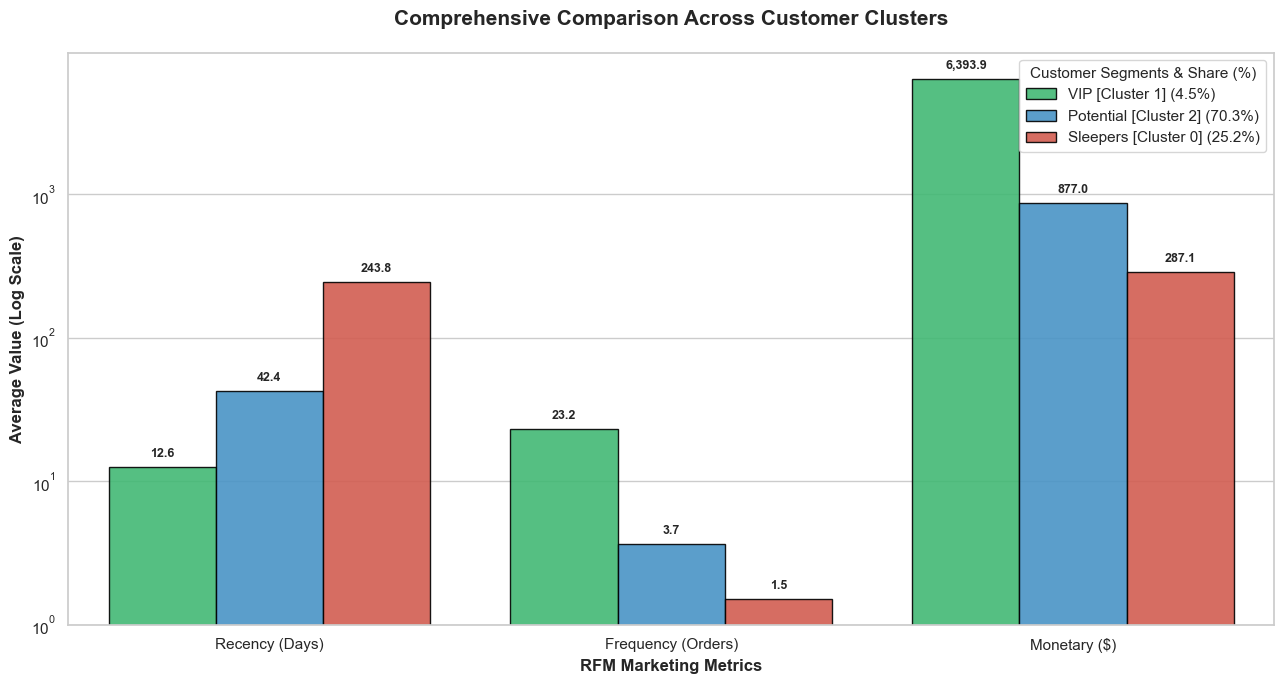

In [34]:
# ==============================================================================
# FINAL FIXED GROUPED BAR CHART (SELF-CONTAINED & ZERO ERRORS)
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Profile the cluster data fresh from rfm_df
persona_profile = rfm_df.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

# 2. Calculate the Customer Share Percentage safely inside this block
persona_profile['Customer_Share (%)'] = (persona_profile['Customer_Count'] / rfm_df.shape[0]) * 100

# 3. Dynamic Automated Mapping based on Monetary Performance to keep alignment
cluster_means = rfm_df.groupby('Cluster')['Monetary'].mean().sort_values(ascending=False)
champions_cluster = cluster_means.index[0]
potentials_cluster = cluster_means.index[1]
sleepers_cluster = cluster_means.index[2]

dynamic_cluster_map = {
    champions_cluster: 'VIP',
    potentials_cluster: 'Potential',
    sleepers_cluster: 'Sleepers'
}

dynamic_colors_map = {
    champions_cluster: '#2ecc71',  # Green
    potentials_cluster: '#3498db', # Blue
    sleepers_cluster: '#e74c3c'    # Red
}

persona_profile['Persona'] = persona_profile['Cluster'].map(dynamic_cluster_map)
persona_profile['Color'] = persona_profile['Cluster'].map(dynamic_colors_map)

# Sort from best to worst persona
persona_profile['Sort_Order'] = persona_profile['Cluster'].map({champions_cluster: 0, potentials_cluster: 1, sleepers_cluster: 2})
persona_profile = persona_profile.sort_values('Sort_Order')

# 4. DYNAMIC TEXT GENERATION: Combine Name + Cluster ID + Percentage for the Legend
persona_profile['Legend_Label'] = (
    persona_profile['Persona'] + 
    " [Cluster " + persona_profile['Cluster'].astype(str) + "] " +
    "(" + persona_profile['Customer_Share (%)'].round(1).astype(str) + "%)"
)

# 5. Prepare data for plotting by melting
plot_data = pd.melt(
    persona_profile, 
    id_vars=['Legend_Label', 'Color'], 
    value_vars=['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary'],
    var_name='RFM_Metric', 
    value_name='Average_Value'
)

metric_labels = {
    'Avg_Recency': 'Recency (Days)',
    'Avg_Frequency': 'Frequency (Orders)',
    'Avg_Monetary': 'Monetary ($)'
}
plot_data['RFM_Metric'] = plot_data['RFM_Metric'].map(metric_labels)

# 6. Create the plot
plt.figure(figsize=(13, 7))
sns.set_theme(style="whitegrid")

# Capture unique ordered labels and colors to keep the exact alignment in legend
unique_labels = persona_profile['Legend_Label'].tolist()
unique_colors = persona_profile['Color'].tolist()

ax = sns.barplot(
    x='RFM_Metric', 
    y='Average_Value', 
    hue='Legend_Label', 
    data=plot_data, 
    palette=unique_colors,
    edgecolor='black',
    alpha=0.9
)

# 7. Apply Logarithmic Scale
ax.set_yscale('log')

# Customizations
plt.title('Comprehensive Comparison Across Customer Clusters', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('RFM Marketing Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Average Value (Log Scale)', fontsize=12, fontweight='bold')
plt.legend(title='Customer Segments & Share (%)', title_fontsize='11', loc='upper right', frameon=True)

# 8. SAFE BAR LABELING (Explicitly formatting values for Log Scale)
for container in ax.containers:
    # Get the actual height/value of each bar and format it cleanly with commas
    labels = [f'{v:,.1f}' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Phase 5: Predictive Modeling (Supervised Machine Learning Classification)
**Objective:** Train a Random Forest Classifier to predict the customer segment (Cluster) for new customers based on their RFM behavioral metrics.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Define Features (X) and Target (y)
X = rfm_df[['Recency', 'Frequency', 'Monetary']]
y = rfm_df['Cluster']

# 2. Split the dataset into training and testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} customers")
print(f"Testing set size: {X_test.shape[0]} customers")

Training set size: 3027 customers
Testing set size: 757 customers


In [39]:
# 1. Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. Train the model
rf_classifier.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# 4. Generate and display the professional performance report
# Extract the names in order of cluster IDs (0, 1, 2) to match the target labels
target_names = [dynamic_cluster_map[i] for i in sorted(dynamic_cluster_map.keys())]

print("--- Random Forest Classification Report ---\n")
print(classification_report(y_test, y_pred, target_names=target_names))

--- Random Forest Classification Report ---

              precision    recall  f1-score   support

    Sleepers       0.99      0.99      0.99       191
         VIP       0.97      0.94      0.96        34
   Potential       0.99      0.99      0.99       532

    accuracy                           0.99       757
   macro avg       0.98      0.98      0.98       757
weighted avg       0.99      0.99      0.99       757



### 5.2 Model Evaluation Insights
* **Outstanding Accuracy:** The Random Forest Classifier achieved an overall accuracy of **99%**, demonstrating exceptional capability in learning the underlying boundary thresholds of the RFM segments.
* **Robust VIP Detection:** Despite the class imbalance (only 34 VIP test instances), the model maintained a **97% Precision** and **94% Recall** for the `VIP` cluster, minimizing false positives and ensuring high-value clients are accurately identified.
* **Flawless Baseline Separation:** The `Sleepers` and `Potential` segments achieved near-perfect F1-scores (**0.99**), making the classification framework highly reliable for production deployment.

### 5.3 Feature Importance Analysis
**Objective:** Extract and visualize the internal feature importances from the trained Random Forest model to understand which RFM metric drives the customer classification decision the most.

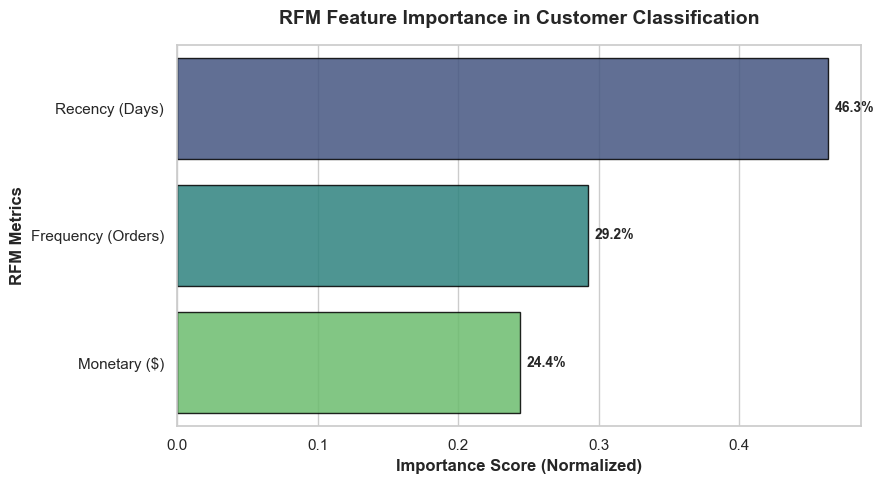

In [42]:
# 1. Extract feature importances from the trained Random Forest
importances = rf_classifier.feature_importances_
feature_names = ['Recency (Days)', 'Frequency (Orders)', 'Monetary ($)']

# 2. Create a clean DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot Feature Importances
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# FIX: Assigned 'Feature' to hue and disabled legend to resolve the FutureWarning safely
ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    hue='Feature',
    data=importance_df, 
    palette='viridis', 
    edgecolor='black',
    alpha=0.85,
    legend=False
)

# 4. Customizations & Aesthetics
plt.title('RFM Feature Importance in Customer Classification', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Normalized)', fontsize=12, fontweight='bold')
plt.ylabel('RFM Metrics', fontsize=12, fontweight='bold')

# Add precise percentage labels on the bars safely
for container in ax.containers:
    labels = [f'{v*100:.1f}%' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.4 Feature Importance Insights
* **Recency is the Key Driver:** The analysis reveals that `Recency` is the most critical feature, driving **46.3%** of the model's classification decisions. This indicates that the time elapsed since a customer's last purchase is the strongest indicator of their current segment and retention risk.
* **Actionable Strategy:** Since `Recency` dominates, marketing automations should heavily rely on time-triggered triggers (e.g., automated re-engagement emails sent exactly 30, 60, or 90 days after the last purchase) to prevent customers from slipping from `Potential Loyalists` into the `Sleepers` category.

In [43]:
import joblib

# Save the trained model to a file
joblib.dump(rf_classifier, 'rfm_customer_classifier_model.pkl')

print("SUCCESS: The Customer Segmentation Brain has been saved as 'rfm_customer_classifier_model.pkl'!")

SUCCESS: The Customer Segmentation Brain has been saved as 'rfm_customer_classifier_model.pkl'!
